In [1]:
from resources.imports import *

from resources.lattices import Geometry, effProperties
from resources.MLdata import DATA, load_data, prep_UTdata, prep_FTdata, prep_MULTIdata, remove_outliers, split_data, \
                             save_MLdata, save_MULTIdata, plot_sampling, locSims, get_stats, plot_frequency, \
                             plot_properties, plot_curve

In [2]:
### Global Inputs

mode = ("compare", "Target-xs")

DAT = DATA(path=1, 
           path_add="",
           load=True,
           LAT="FCC", 
           dis="disNodes", 
           dN=0.2,
           mechMode="both",
           multi=True)

if mode is not None:
    if mode[0].lower() == "compare":
        DATc = DATA(path=1, 
                    path_add=mode[1],
                    load=DAT.load,
                    LAT=DAT.LAT, 
                    dis=DAT.dis, 
                    dN=DAT.dN,
                    mechMode=DAT.mechMode,
                    multi=DAT.multi)

if DAT.LAT.lower() == "fcc":
    manual_outliersUT = None
    manual_outliersFT = None
elif DAT.LAT.lower() == "kagome":
    manual_outliersUT = None
    manual_outliersFT = None
elif DAT.LAT.lower() == "hex":
    manual_outliersUT = None
    manual_outliersFT = None
elif DAT.LAT.lower() == "tri":
    manual_outliersUT = None
    manual_outliersFT = None

c:\Users\exy053\OneDrive - Queen Mary, University of London\Documents\Research\p1-LatticeFractureToughness\p1git-Lattices\code\resources\lattices.py:637: RuntimeWarning: divide by zero encountered in double_scalars
  return np.array([np.cos(np.arctan([n0[1]/n0[0]]))[0], np.sin(np.arctan([n0[1]/n0[0]]))[0]])


# Load Data

In [3]:
if DAT.load is not True:
    if DAT.UTmechTest:
        DAT.UT_INcsv  = DAT.PATH + f'Ductile-{DAT.dis}-IN.csv'
        DAT.UT_OUTcsv = DAT.PATH + f'Ductile-{DAT.dis}-OUT.csv'
        DAT.UT_INcsv_f = None
        if DAT.freq:
            DAT.UT_INcsv_f = DAT.PATH + f'Ductile-{DAT.dis}-INf.csv'

    if DAT.FTmechTest:
        DAT.FT_INcsv  = DAT.PATH + f'Fracture-{DAT.dis}-IN.csv'
        DAT.FT_OUTcsv = DAT.PATH + f'Fracture-{DAT.dis}-OUT.csv'
        DAT.FT_INcsv_f = None
        if DAT.freq:
            DAT.FT_INcsv_f = DAT.PATH + f'Fracture-{DAT.dis}-INf.csv'

    if mode is not None and mode[0].lower() == "compare":
        if DATc.UTmechTest:
            DATc.UT_INcsv  = DATc.PATH + f'Ductile-{DATc.dis}-IN.csv'
            DATc.UT_OUTcsv = DATc.PATH + f'Ductile-{DATc.dis}-OUT.csv'
            DATc.UT_INcsv_f = None
            if DATc.freq:
                DATc.UT_INcsv_f = DATc.PATH + f'Ductile-{DATc.dis}-INf.csv'

        if DATc.FTmechTest:
            DATc.FT_INcsv  = DATc.PATH + f'Fracture-{DATc.dis}-IN.csv'
            DATc.FT_OUTcsv = DATc.PATH + f'Fracture-{DATc.dis}-OUT.csv'
            DATc.FT_INcsv_f = None
            if DATc.freq:
                DATc.FT_INcsv_f = DATc.PATH + f'Fracture-{DATc.dis}-INf.csv'

In [4]:
if DAT.load is not True:
    if DAT.UTmechTest:
        DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_INf_df, DAT.UT_perINr_df, DAT.UT_perIN_df, DAT.UT_perOUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df = load_data(DAT.UT_INcsv, DAT.UT_OUTcsv, DAT.UT_INcsv_f)

    if DAT.FTmechTest:
        DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_INf_df, DAT.FT_perINr_df, DAT.FT_perIN_df, DAT.FT_perOUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df = load_data(DAT.FT_INcsv, DAT.FT_OUTcsv, DAT.FT_INcsv_f)

    if mode is not None and mode[0].lower() == "compare":
        if DATc.UTmechTest:
            DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_INf_df, DATc.UT_perINr_df, DATc.UT_perIN_df, DATc.UT_perOUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df = load_data(DATc.UT_INcsv, DATc.UT_OUTcsv, DATc.UT_INcsv_f)

        if DATc.FTmechTest:
            DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_INf_df, DATc.FT_perINr_df, DATc.FT_perIN_df, DATc.FT_perOUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df = load_data(DATc.FT_INcsv, DATc.FT_OUTcsv, DATc.FT_INcsv_f)

# Geometry

In [5]:
if DAT.load is not True:
    DAT.geom.FTcalc()

# Prep Data

In [6]:
if DAT.load is not True:
    if DAT.UTmechTest:
        DAT.UT_dIN_r, DAT.UT_dOUT_r, DAT.UT_INf_r, DAT.UT_xOUT, DAT.UT_allProps_r, DAT.UT_allProps_r_df = prep_UTdata(DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_perOUT_df, DAT.UT_OUT_df, DAT.UT_INf_df)
        DAT.UT_dIN, DAT.UT_dOUT, DAT.UT_INf, DAT.UT_allProps, DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_allProps_df, DAT.UT_INf_df = remove_outliers(DAT.UT_dIN_r, DAT.UT_dOUT_r, DAT.UT_allProps_r, DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_allProps_r_df, DAT.UT_INf_r, DAT.UT_INf_df, manual=manual_outliersUT)
        DAT.UT_train, DAT.UT_val, DAT.UT_test, DAT.UT_split_idxs = split_data(DAT.UT_dIN[1:], DAT.UT_dOUT[1:], DAT.UT_allProps, DAT.UT_INf, split=0.85)
        save_MLdata(DAT.UT_perIN_df, DAT.UT_perOUT_df, DAT.UT_train, DAT.UT_val, DAT.UT_test, DAT.UT_IN_df, DAT.UT_OUT_df, DAT.UT_dIN_df, DAT.UT_dOUT_df, DAT.UT_INf_df, DAT.UT_allProps_df, DAT.PATH, "UT", DAT.dis)

    if DAT.FTmechTest:
        DAT.FT_dIN_r, DAT.FT_dOUT_r, DAT.FT_INf_r, DAT.FT_xOUT, DAT.FT_allProps_r, DAT.FT_allProps_r_df = prep_FTdata(DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_perOUT_df, DAT.FT_OUT_df, DAT.geom, DAT.E_eff_pe, DAT.FT_INf_df)
        DAT.FT_dIN, DAT.FT_dOUT, DAT.FT_INf, DAT.FT_allProps, DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_allProps_df, DAT.FT_INf_df = remove_outliers(DAT.FT_dIN_r, DAT.FT_dOUT_r, DAT.FT_allProps_r, DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_allProps_r_df, DAT.FT_INf_r, DAT.FT_INf_df, manual=manual_outliersFT)
        DAT.FT_train, DAT.FT_val, DAT.FT_test, DAT.FT_split_idxs = split_data(DAT.FT_dIN[1:], DAT.FT_dOUT[1:], DAT.FT_allProps, DAT.FT_INf, split=0.85)
        save_MLdata(DAT.FT_perIN_df, DAT.FT_perOUT_df, DAT.FT_train, DAT.FT_val, DAT.FT_test, DAT.FT_IN_df, DAT.FT_OUT_df, DAT.FT_dIN_df, DAT.FT_dOUT_df, DAT.FT_INf_df, DAT.FT_allProps_df, DAT.PATH, "FT", DAT.dis)

    if DAT.UTmechTest and DAT.FTmechTest:
        DAT.common_allProps_df, DAT.common_IN_dfs, DAT.common_OUT_dfs, DAT.common_dIN_dfs, DAT.common_dOUT_dfs, DAT.common_INf_dfs = prep_MULTIdata([DAT.UT_IN_df, DAT.FT_IN_df], [DAT.UT_OUT_df, DAT.FT_OUT_df], [DAT.UT_dIN_df, DAT.FT_dIN_df] , [DAT.UT_dOUT_df, DAT.FT_dOUT_df], [DAT.UT_allProps_df, DAT.FT_allProps_df], [DAT.UT_INf_df, DAT.FT_INf_df], DAT.E_eff_pe)
        save_MULTIdata(DAT.common_IN_dfs, DAT.common_OUT_dfs, DAT.common_dIN_dfs, DAT.common_dOUT_dfs, DAT.common_allProps_df, DAT.common_INf_dfs, DAT.PATH, DAT.dis)

    if mode is not None and mode[0].lower() == "compare":
        if DATc.UTmechTest:
            DATc.UT_dIN_r, DATc.UT_dOUT_r, DATc.UT_INf_r, DATc.UT_xOUT, DATc.UT_allProps_r, DATc.UT_allProps_r_df = prep_UTdata(DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_perOUT_df, DATc.UT_OUT_df, DATc.UT_INf_df)
            DATc.UT_dIN, DATc.UT_dOUT, DATc.UT_INf, DATc.UT_allProps, DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_allProps_df, DATc.UT_INf_df = remove_outliers(DATc.UT_dIN_r, DATc.UT_dOUT_r, DATc.UT_allProps_r, DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_allProps_r_df, DATc.UT_INf_r, DATc.UT_INf_df, manual=manual_outliersFT)
            DATc.UT_train, DATc.UT_val, DATc.UT_test, DATc.UT_split_idxs = split_data(DATc.UT_dIN[1:], DATc.UT_dOUT[1:], DATc.UT_allProps, DATc.UT_INf, split=0.85)
            save_MLdata(DATc.UT_perIN_df, DATc.UT_perOUT_df, DATc.UT_train, DATc.UT_val, DATc.UT_test, DATc.UT_IN_df, DATc.UT_OUT_df, DATc.UT_dIN_df, DATc.UT_dOUT_df, DATc.UT_INf_df, DATc.UT_allProps_df, DATc.PATH, "UT", DATc.dis)
        
        if DATc.FTmechTest:
            DATc.FT_dIN_r, DATc.FT_dOUT_r, DATc.FT_INf_r, DATc.FT_xOUT, DATc.FT_allProps_r, DATc.FT_allProps_r_df = prep_FTdata(DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_perOUT_df, DATc.FT_OUT_df, DATc.geom, DATc.E_eff_pe, DATc.FT_INf_df)
            DATc.FT_dIN, DATc.FT_dOUT, DATc.FT_INf, DATc.FT_allProps, DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_allProps_df, DATc.FT_INf_df = remove_outliers(DATc.FT_dIN_r, DATc.FT_dOUT_r, DATc.FT_allProps_r, DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_allProps_r_df, DATc.FT_INf_r, DATc.FT_INf_df, manual=manual_outliersFT)
            DATc.FT_train, DATc.FT_val, DATc.FT_test, DATc.FT_split_idxs = split_data(DATc.FT_dIN[1:], DATc.FT_dOUT[1:], DATc.FT_allProps, DATc.FT_INf, split=0.85)
            save_MLdata(DATc.FT_perIN_df, DATc.FT_perOUT_df, DATc.FT_train, DATc.FT_val, DATc.FT_test, DATc.FT_IN_df, DATc.FT_OUT_df, DATc.FT_dIN_df, DATc.FT_dOUT_df, DATc.FT_INf_df, DATc.FT_allProps_df, DATc.PATH, "FT", DATc.dis)

        if DATc.UTmechTest and DATc.FTmechTest:
            DATc.common_allProps_df, DATc.common_IN_dfs, DATc.common_OUT_dfs, DATc.common_dIN_dfs, DATc.common_dOUT_dfs, DATc.common_INf_dfs = prep_MULTIdata([DATc.UT_IN_df, DATc.FT_IN_df], [DATc.UT_OUT_df, DATc.FT_OUT_df], [DATc.UT_dIN_df, DATc.FT_dIN_df] , [DATc.UT_dOUT_df, DATc.FT_dOUT_df], [DATc.UT_allProps_df, DATc.FT_allProps_df], [DATc.UT_INf_df, DATc.FT_INf_df], DATc.E_eff_pe)
            save_MULTIdata(DATc.common_IN_dfs, DATc.common_OUT_dfs, DATc.common_dIN_dfs, DATc.common_dOUT_dfs, DATc.common_allProps_df, DATc.common_INf_dfs, DATc.PATH, DATc.dis)

In [7]:
# plot_sampling(DAT.UT_dIN_df, DAT.LAT, DAT.geom.l, indx=None, num=1, by="Node")

In [8]:
if DAT.UTmechTest:
    DAT.UT_stats = get_stats(DAT.UT_allProps_df)
    DAT.UT_nSims = locSims(DAT.UT_allProps_df)
    print("FINAL UT SIMULATION COUNT:", len(DAT.UT_OUT_df)-1)
    print(f"{pd.concat([DAT.UT_stats, DAT.UT_nSims])}\n\n")
    print(f"{(DAT.UT_stats-DAT.UT_allProps_df.iloc[0])/DAT.UT_allProps_df.iloc[0]}\n\n")

if DAT.FTmechTest:
    DAT.FT_stats = get_stats(DAT.FT_allProps_df)
    DAT.FT_nSims = locSims(DAT.FT_allProps_df)
    print("FINAL FT SIMULATION COUNT:", len(DAT.FT_OUT_df)-1)
    print(f"{pd.concat([DAT.FT_stats, DAT.FT_nSims])}\n\n")
    print(f"{(DAT.FT_stats-DAT.FT_allProps_df.iloc[0])/DAT.FT_allProps_df.iloc[0]}\n\n")

if DAT.UTmechTest and DAT.FTmechTest and DAT.multi:
    DAT.common_stats = get_stats(DAT.common_allProps_df)
    DAT.common_nSims = locSims(DAT.common_allProps_df)
    print("FINAL COMMON SIMULATION COUNT:", len(DAT.common_allProps_df)-1)
    print(f"{pd.concat([DAT.common_stats, DAT.common_nSims])}\n\n")
    print(f"{(DAT.common_stats-DAT.common_allProps_df.iloc[0])/DAT.common_allProps_df.iloc[0]}\n\n")

if mode is not None and mode[0].lower() == "compare":
    print("\n=============== COMPARISON DATA ===============\n")
    if DATc.UTmechTest:
        DATc.UT_stats = get_stats(DATc.UT_allProps_df)
        DATc.UT_nSims = locSims(DATc.UT_allProps_df)
        print("FINAL UT SIMULATION COUNT:", len(DATc.UT_OUT_df)-1)
        print(f"{pd.concat([DATc.UT_stats, DATc.UT_nSims])}\n\n")
        print(f"{(DATc.UT_stats-DATc.UT_allProps_df.iloc[0])/DATc.UT_allProps_df.iloc[0]}\n\n")

    if DATc.FTmechTest:
        DATc.FT_stats = get_stats(DATc.FT_allProps_df)
        DATc.FT_nSims = locSims(DATc.FT_allProps_df)
        print("FINAL FT SIMULATION COUNT:", len(DATc.FT_OUT_df)-1)
        print(f"{pd.concat([DATc.FT_stats, DATc.FT_nSims])}\n\n")
        print(f"{(DATc.FT_stats-DATc.FT_allProps_df.iloc[0])/DATc.FT_allProps_df.iloc[0]}\n\n")

    if DATc.UTmechTest and DATc.FTmechTest and DAT.multi:
        DATc.common_stats = get_stats(DATc.common_allProps_df)
        DATc.common_nSims = locSims(DATc.common_allProps_df)
        print("FINAL COMMON SIMULATION COUNT:", len(DATc.common_allProps_df)-1)
        print(f"{pd.concat([DATc.common_stats, DATc.common_nSims])}\n\n")
        print(f"{(DATc.common_stats-DATc.common_allProps_df.iloc[0])/DATc.common_allProps_df.iloc[0]}\n\n")

FINAL UT SIMULATION COUNT: 6817
        Ductility     Strength    Stiffness          WoF         K_JIC  \
Mean     0.032457    60.325897  7250.890297     1.482815  3.174620e+07   
Std      0.004133     0.682754    16.899177     0.149059  3.233027e+06   
Max   2202.000000  1464.000000  2033.000000  2202.000000  6.084000e+03   
Min    944.000000  6213.000000  1057.000000  4661.000000  5.040000e+03   

              K_IC         Force  Displacement        Multi          FCL  
Mean  2.430070e+07  80774.129761      0.006281     5.579174     0.096379  
Std   1.249777e+06   4154.187779      0.000875     0.613968     0.022812  
Max   2.860000e+02    286.000000   1025.000000  6812.000000  3129.000000  
Min   2.949000e+03   2949.000000    447.000000  2094.000000  3804.000000  


      Ductility  Strength  Stiffness       WoF     K_JIC      K_IC     Force  \
Mean   0.289359 -0.050131  -0.019406  0.032392 -0.062916 -0.106007 -0.106007   
Std   -0.835816 -0.989250  -0.997715 -0.896219 -0.904568 -0.

In [9]:
if DAT.UTmechTest:
    print(f"{(DAT.UT_allProps_df.loc[DAT.UT_nSims['Ductility'].loc['Max']]-DAT.UT_allProps_df.iloc[0])/DAT.UT_allProps_df.iloc[0]}\n\n")

if DAT.FTmechTest:
    print(f"{(DAT.FT_allProps_df.loc[DAT.FT_nSims['K_JIC'].loc['Max']]-DAT.FT_allProps_df.iloc[0])/DAT.FT_allProps_df.iloc[0]}\n\n")

if DAT.UTmechTest and DAT.FTmechTest and DAT.multi:
    print(f"{(DAT.common_allProps_df.loc[DAT.common_nSims['FCL'].loc['Max']]-DAT.common_allProps_df.iloc[0])/DAT.common_allProps_df.iloc[0]}\n\n")
    print(f"{(DAT.common_allProps_df.loc[DAT.common_nSims['Multi'].loc['Max']]-DAT.common_allProps_df.iloc[0])/DAT.common_allProps_df.iloc[0]}\n\n")

if mode is not None and mode[0].lower() == "compare":
    print("\n=============== COMPARISON DATA ===============\n")
    if DATc.UTmechTest:
        print(f"{(DATc.UT_allProps_df.loc[DATc.UT_nSims['Ductility'].loc['Max']]-DATc.UT_allProps_df.iloc[0])/DATc.UT_allProps_df.iloc[0]}\n\n")

    if DATc.FTmechTest:
        print(f"{(DATc.FT_allProps_df.loc[DATc.FT_nSims['K_JIC'].loc['Max']]-DATc.FT_allProps_df.iloc[0])/DATc.FT_allProps_df.iloc[0]}\n\n")

    if DATc.UTmechTest and DATc.FTmechTest and DAT.multi:
        print(f"{(DATc.common_allProps_df.loc[DATc.common_nSims['FCL'].loc['Max']]-DATc.common_allProps_df.iloc[0])/DATc.common_allProps_df.iloc[0]}\n\n")
        print(f"{(DATc.common_allProps_df.loc[DATc.common_nSims['Multi'].loc['Max']]-DATc.common_allProps_df.iloc[0])/DATc.common_allProps_df.iloc[0]}\n\n")

Ductility       0.940476
Strength       -0.029325
Stiffness      -0.015800
WoF             0.346331
K_JIC          -0.095464
K_IC           -0.114666
Force          -0.114666
Displacement   -0.049383
Multi           0.570251
FCL            -0.392285
dtype: float64


Ductility       0.500000
Strength       -0.057211
Stiffness      -0.019644
WoF             0.113834
K_JIC           0.231384
K_IC           -0.012906
Force          -0.012906
Displacement    0.469136
Multi           0.458413
FCL             0.361341
dtype: float64


Ductility       0.083333
Strength       -0.065317
Stiffness      -0.016585
WoF            -0.204085
K_JIC           0.220101
K_IC           -0.013741
Force          -0.013741
Displacement    0.456790
Multi           0.169929
FCL             0.870358
dtype: float64


Ductility       0.869048
Strength       -0.057083
Stiffness      -0.019103
WoF             0.239485
K_JIC           0.191131
K_IC           -0.034437
Force          -0.034437
Displacement    0.419753

In [10]:
# FT_OUT_df.index.get_loc(FT_OUT_df[FT_OUT_df.index == 182].index[0])

# Plot Distribution & Identify Max, Min Simulations

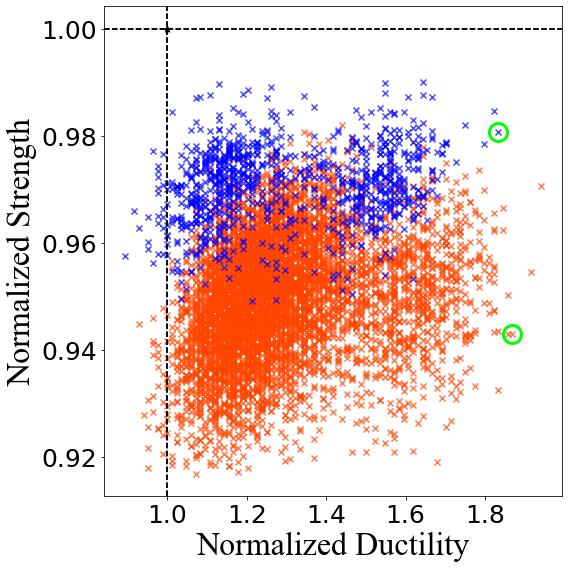

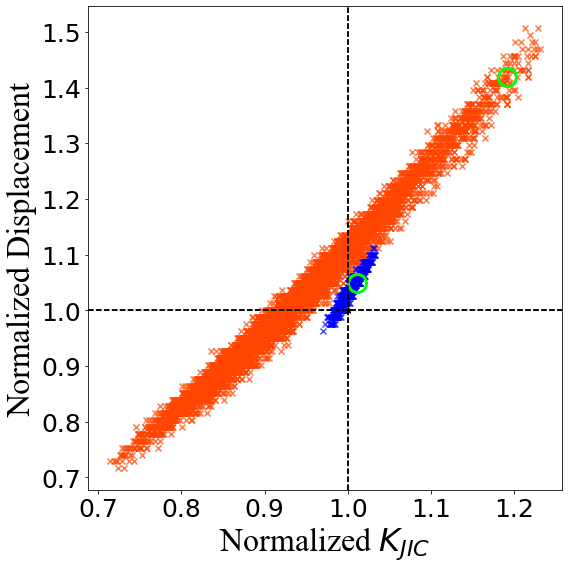

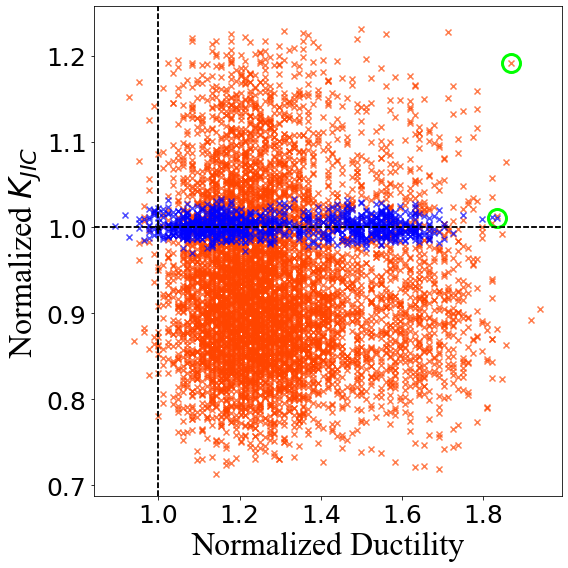

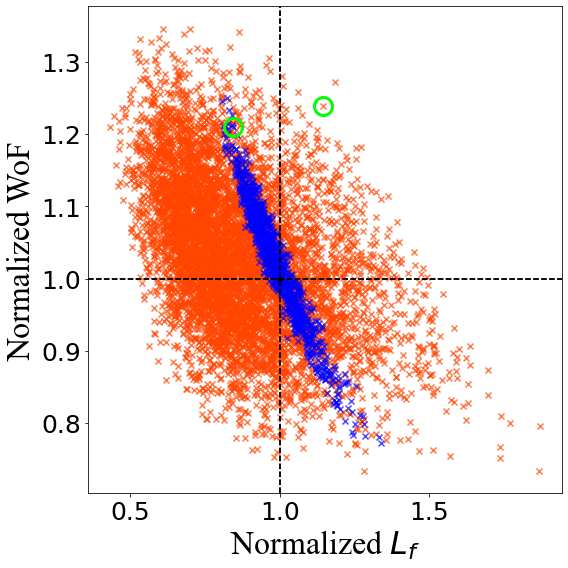

In [11]:
plot_allProps = True
plot_freq = False
plot_ONLY_freq = False

if plot_allProps:
    if DAT.UTmechTest:  
        fig, ax = plot_properties(DAT.UT_allProps_df["Ductility"], DAT.UT_allProps_df["Strength"], "UT", include_freq=plot_freq, compare_ax=None, highlight=[DAT.common_nSims["Multi"].loc["Max"]] if DAT.multi else None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.UT_allProps_df["Ductility"], DATc.UT_allProps_df["Strength"], "UT", include_freq=plot_freq, compare_ax=(fig, ax), highlight=[DATc.common_nSims["Multi"].loc["Max"]] if DAT.multi else None)
    
    if DAT.FTmechTest:  
        fig, ax = plot_properties(DAT.FT_allProps_df["K_JIC"], DAT.FT_allProps_df["Displacement"], "FT", include_freq=plot_freq, compare_ax=None, highlight=[DAT.common_nSims["Multi"].loc["Max"]] if DAT.multi else None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.FT_allProps_df["K_JIC"], DATc.FT_allProps_df["Displacement"], "FT", include_freq=plot_freq, compare_ax=(fig, ax), highlight=[DATc.common_nSims["Multi"].loc["Max"]] if DAT.multi else None)
   
    if DAT.UTmechTest and DAT.FTmechTest and DAT.multi:   
        fig, ax = plot_properties(DAT.common_allProps_df["Ductility"], DAT.common_allProps_df["K_JIC"], "MULTI", include_freq=plot_freq, compare_ax=None, highlight=[DAT.common_nSims["Multi"].loc["Max"]] if DAT.multi else None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.common_allProps_df["Ductility"], DATc.common_allProps_df["K_JIC"], "MULTI", include_freq=plot_freq, compare_ax=(fig, ax), highlight=[DATc.common_nSims["Multi"].loc["Max"]] if DAT.multi else None)
            
        fig, ax = plot_properties(DAT.common_allProps_df["FCL"], DAT.common_allProps_df["WoF"], "FCL", include_freq=plot_freq, compare_ax=None, highlight=[DAT.common_nSims["Multi"].loc["Max"]] if DAT.multi else None)
        if mode is not None and mode[0].lower() == "compare":
            fig, ax = plot_properties(DATc.common_allProps_df["FCL"], DATc.common_allProps_df["WoF"], "FCL", include_freq=plot_freq, compare_ax=(fig, ax), highlight=[DATc.common_nSims["Multi"].loc["Max"]] if DAT.multi else None)

if plot_ONLY_freq and DAT.load is not True:
    if DAT.UTmechTest:
        plot_frequency(DAT.UT_allProps_r_df["Ductility"], DAT.UT_allProps_df["Ductility"], "UT", bins=30)
    if DAT.FTmechTest:
        plot_frequency(DAT.FT_allProps_r_df["K_JIC"], DAT.FT_allProps_df["K_JIC"], "FT", bins=30)
    if DAT.UTmechTest and DAT.FTmechTest and DAT.multi:
        plot_frequency(DAT.common_allProps_df["FCL"], DAT.common_allProps_df["FCL"], "FCL", bins=30)

# Plots UT and FT Curves

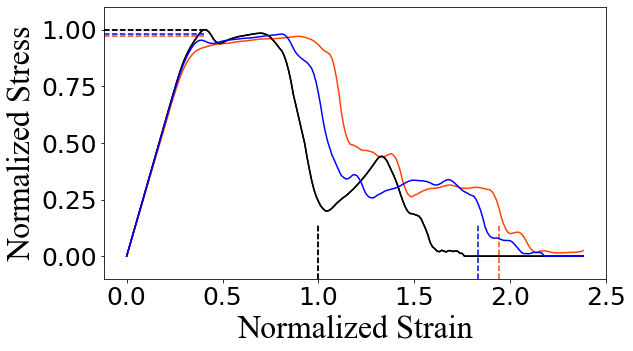

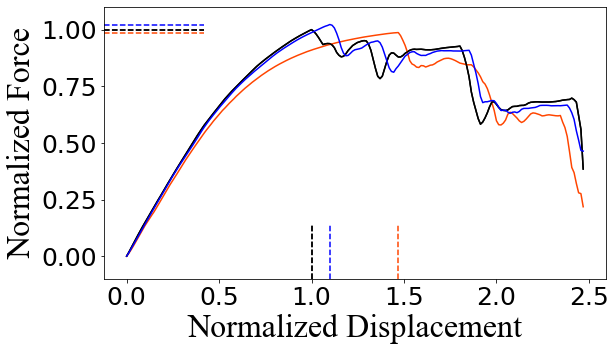

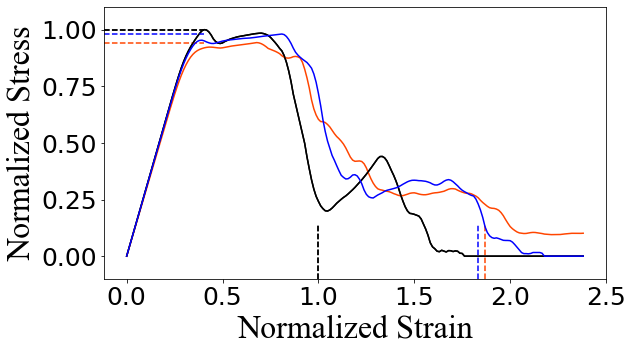

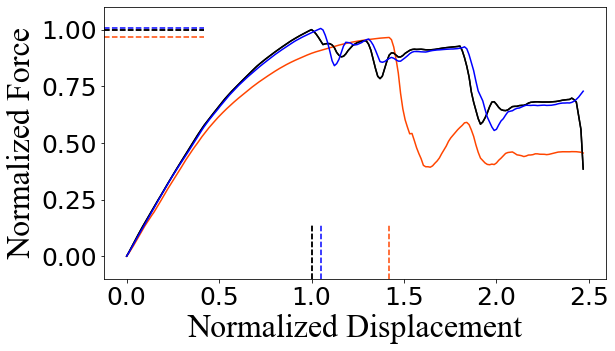

In [12]:
idx = None
q   = "all"
if DAT.UTmechTest:
    fig2, ax1 = plot_curve(DAT.UT_OUT_df, DAT.UT_xOUT, "ut", pi=0, idx=[DAT.UT_nSims["Ductility"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.UT_OUT_df, DATc.UT_xOUT, "ut", pi=0, idx=[DATc.UT_nSims["Ductility"].loc["Max"]], q='all', compare_ax=(fig2, ax1))
    
if DAT.FTmechTest:
    fig2, ax1 = plot_curve(DAT.FT_OUT_df, DAT.FT_xOUT, "ft", pi=0, idx=[DAT.FT_nSims["K_JIC"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.FT_OUT_df, DATc.FT_xOUT, "ft", pi=0, idx=[DATc.FT_nSims["K_JIC"].loc["Max"]], q='all', compare_ax=(fig2, ax1))
    
if DAT.UTmechTest and DAT.FTmechTest and DAT.multi:
    fig2, ax1 = plot_curve(DAT.UT_OUT_df, DAT.UT_xOUT, "ut", pi=0, idx=[DAT.common_nSims["Multi"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.UT_OUT_df, DATc.UT_xOUT, "ut", pi=0, idx=[DATc.common_nSims["Multi"].loc["Max"]], q='all', compare_ax=(fig2, ax1))
        
    fig2, ax1 = plot_curve(DAT.FT_OUT_df, DAT.FT_xOUT, "ft", pi=0, idx=[DAT.common_nSims["Multi"].loc["Max"]], q='all', compare_ax=None)
    if mode is not None and mode[0].lower() == "compare":
        fig2, ax1 = plot_curve(DATc.FT_OUT_df, DATc.FT_xOUT, "ft", pi=0, idx=[DATc.common_nSims["Multi"].loc["Max"]], q='all', compare_ax=(fig2, ax1))